# Tutorial 3: Fixed dimension MCMC with Eryn

In [ ]:
# # if running in google colab
# !pip install eryn lisaanalysistools

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from lisatools.utils.constants import *
from copy import deepcopy  # can be useful

In the third tutorial, we are going to learn how to use MCMC through `Eryn` to do our data analysis investigations. In this tutorial, we will stick with simple examples and simple signals (like in Tutorial 1). In later tutorials, we will use eryn with real GW signals. 

## Task 1: build your own basic MCMC

In order to better understand MCMC and `Eryn`, we are going to start by building our own MCMC algorithm for a simple problem. We will do this with a single-dimensional Gaussian likelihood centered on ($\mu=0$) and a unit standard deviation ($\sigma=1$) and a uniform prior. 

In [2]:
def log_like_gauss(x):
    return -0.5 * x ** 2 - 1/2 * np.log(2 * np.pi * 1.0) # 1.0 is sigma

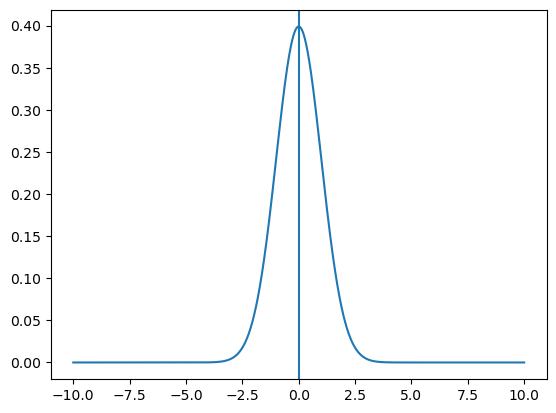

In [3]:
x_vals = np.linspace(-10.0, 10.0, 1000)
# notice the `exp` in there because we are working with the log of the likelihood.
plt.plot(x_vals, np.exp(log_like_gauss(x_vals)))
plt.axvline(0.0)

We are just going to write this into a simple loop. Gather your samples into the chain list.

In [8]:
num_steps = 100000
# get random starting point
current_point = np.random.uniform(-10.0, 10.0)
# np.random.uniform(a, b) generates a random float uniformly in the range [a, b). 
# In this case, it generates a random float between -10.0 and 10.0.
current_likelihood = log_like_gauss(current_point)
chain = []
for step in range(num_steps):
    # propose new point using a Gaussian distribution with standard deviation of 0.5
    # hint: use current + sigma * N() where N() is a draw from a normal distribution 
    # (np.random.randn)
    proposed_point = current_point + 0.5 * np.random.randn()

    # get new likelihood
    proposed_likelihood = log_like_gauss(proposed_point)

    # calculate the change in posterior
    log_posterior_change = proposed_likelihood - current_likelihood
    # here we are using a uniform prior, so its value will not change, so for now do not
    # worry about the prior.


    # accept or reject
    # if change in log posterior is greater than log(np.random.rand()), accept, else reject
    # 4. 决定走不走 (accept or reject)
    # 这是 MCMC 的灵魂所在！
    # 如果是上坡 (delta_log_like > 0)，因为 np.log(0到1之间的小数) 永远是负数，所以 accept 必定为 True！(无脑往高处走)
    # 如果是下坡 (delta_log_like < 0)，他也会抛个硬币。只要下坡不太陡，他就有一定的概率往下走。(为了防止被困在半山腰的假山顶)
    if log_posterior_change > np.log(np.random.rand()):
        accept = True
    else:
        accept = False
    # 也可以写为 accpet=log_posterior_change > np.log(np.random.rand())，因为这个条件本身就会返回一个布尔值。
    # np.random.rand()：生成一个0到1之间的随机数，np.log()：取自然对数。
    if accept:
        current_point = proposed_point
        current_likelihood = proposed_likelihood


    # append point to chain
    chain.append(current_point)
    # 注意这里我们 append 的是 current_point 而不是 proposed_point，因为我们要记录的是 MCMC 实际走过的路径，而不是每次提议的点。
    # 如果 proposed_point 被接受了，那么 current_point 就会更新为 proposed_point；如果 proposed_point 被拒绝了，那么 current_point 就保持不变。
    # 无论如何，我们都要记录 current_point，因为它代表了 MCMC 实际走过的路径。

Now plot the chain. You will notice that the beginnning requires a "burn in" phase. **So, when calculating the posterior, you must remove this.** There are ways to calculate how much burn in is appropriate, but we will not get into that here. 

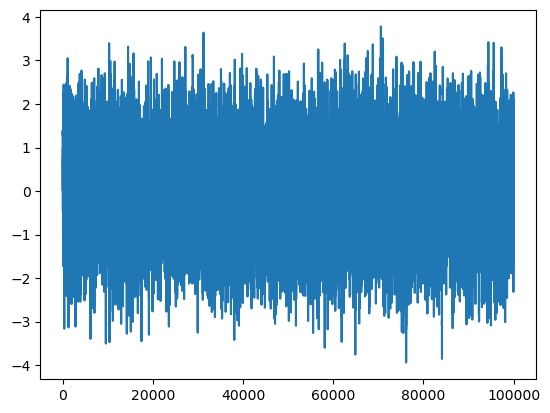

In [9]:
plt.plot(chain)

Plot the posterior distribution generated by the MCMC and compare it against the true Likelihood plot from above. Remember to set `density=True` when building the histogram.

If we take a step back here, we realize MCMC is really just a way to draw samples from a distribution. When the distribution is simple like this example, it will usually be available already with no need to run MCMC (like in scipy). However, in our area of work, the Likelihood distribution tends to be very difficult to deal with, which is why MCMC is so useful for us. To illustrate this, we will draw samples from the same distribution available in Numpy (`np.random.randn`).

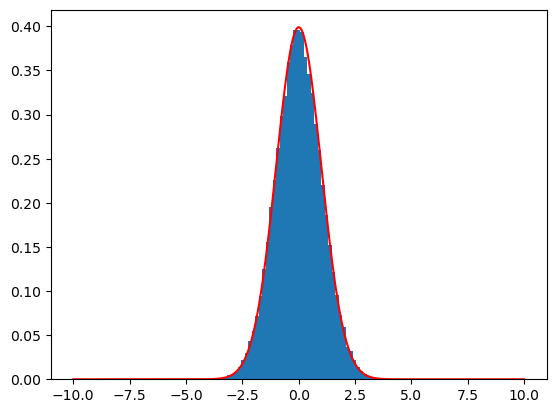

In [10]:
# Plot the posterior distribution generated by the MCMC and compare it against the true Likelihood plot from above. Remember to set `density=True` when building the histogram.
plt.hist(chain, bins=50, density=True)
#plt.hist(chain, bins=50, density=True) 会将直方图归一化，使得总面积为1，这样就可以直接与概率密度函数进行比较。
# density=True 的作用是将直方图归一化，使得每个 bin 的高度表示该区间内的概率密度，而不是频数。
# 这对于比较 MCMC 生成的样本分布与理论概率密度函数非常重要。
plt.plot(x_vals, np.exp(log_like_gauss(x_vals)), color='red')


**为何叫马尔科夫？**

高中的时候，学过马尔可夫链，也就是概率中，前面的概率会影响后一次的概率，后一次的位置是由前一次决定的。（似乎是这样的，比如醉汉行走）。醉汉下一步迈向哪里，只取决于他现在脚踩的这个位置（当前状态），而与他之前是怎么走过来的（历史路径）毫无关系。

我们给出了Likehood似然函数，“醉汉”（$x$是一个参数）在这样的函数上行走，这样的似然函数意味着$x=0$是模型和真实的物理信号最符合的，也就是似然函数最大的时候。

醉汉是怎么行走的呢？如果随机向左右行走，如果这个值比走之前变大了，则更新这个值。下一步继续随机，如果下降了，并不是回到前一步，而是“抛硬币”决定。**这是非常重要的，因为存在局域最大值，如果就停在原地了，可能会被困到较低的山顶上**。

所以醉汉也就是$x$在什么位置，是和前一次向哪走有关的。

**为何叫蒙特卡洛？**

蒙特卡洛似乎说的是，通过概率去复现一个东西，随机撒一些点。（大概是这样的）在计算物理中，它代表用随机采样的统计魔法，去暴力破解极其复杂的微积分问题。

我们在最后统计的时候，上面的随机行走，我们发现其会倾向于在最大值（我们设定的规矩），这似乎就是随便撒了一些点，然后根据概率统计出来的。给出的最后概然的结果吧

**MCMC可以帮我们干什么？**

在真实的世界中，我们的似然函数不会是这样的，它是无解析表达的。这样我们也只能通过这样的方式去寻找最符合真实信号的参数了！

## Task 2: Use Eryn to reproduce the above result.

Now use the `EnsembleSampler` in `Eryn` to reproduce the above results. If you are struggling, look at the `Eryn` tutorial. For Eryn, you will need to define a prior. Use `uniform_dist` to create a simple uniform distribution. For this example, you only need to worry about the Ensemble Sampler keyword arguments. Leave those all as default values and only enter the arguments.

Useful documentation:
* [EnsembleSampler](https://mikekatz04.github.io/Eryn/html/user/ensemble.html#eryn.ensemble.EnsembleSampler)
* [State](https://mikekatz04.github.io/Eryn/html/user/state.html#eryn.state.State)
* [uniform_dist](https://mikekatz04.github.io/Eryn/html/user/prior.html#eryn.prior.uniform_dist)
* [ProbDistContainer](https://mikekatz04.github.io/Eryn/html/user/prior.html#eryn.prior.ProbDistContainer)

In [11]:
# imports
from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.prior import uniform_dist, ProbDistContainer

Initialize your sampler here. The prior initialization should take the form: `ProbDistContainer({0: prior distribution})`.

In [12]:
# 1. 定义先验 (Prior)
# 只有一个参数，我们给它一个均匀分布的先验，范围是 -10 到 10。
prior = ProbDistContainer({
    0: uniform_dist(-10.0, 10.0) 
})
# 2. 初始化 Eryn 采样器 (EnsembleSampler)
nwalkers = 20  # 我们雇佣 20 个漫步者（醉汉）同时去搜索
ndim = 1       # 参数的维度只有 1 维（也就是 x）
# 只传入核心参数，其他关键字参数（kwargs）留作默认值
sampler = EnsembleSampler(
    nwalkers, 
    ndim, 
    log_like_gauss,  # 这就是你之前用的那个高斯似然函数
    priors=prior
)

Now choose your starting point (one for each walker). You can draw from the prior or not. Just make sure to remove any burn in（预热期） at the end. Then put the starting point into a `State` object. The key here is the start point should have shape `(1, nwalkers, 1, ndim)`. Here the two 1s are for temperatures (which we are not using right now) and the number of leaves or model count (this is for RJ). After this is complete, run the sampler.

Documentation:
* [run_mcmc](https://mikekatz04.github.io/Eryn/html/user/ensemble.html#eryn.ensemble.EnsembleSampler.run_mcmc)

In [13]:
import numpy as np

# 1. 定义一个正式的“翻译官”函数
def my_in1d_replacement(ar1, ar2, assume_unique=False, invert=False):
    """
    这个函数的作用是：接到旧指令，转发给新函数
    """
    return np.isin(ar1, ar2, assume_unique=assume_unique, invert=invert)

# 2. 如果 numpy 丢了东西，就把这个“翻译官”派驻到 numpy 里面去
if not hasattr(np, 'in1d'):
    np.in1d = my_in1d_replacement

In [14]:
startpoint=np.random.uniform(-10.0, 10.0, size=(1,nwalkers,1, ndim))  
# 每个漫步者的初始位置随机分布在 -10 到 10 之间
#np.random.uniform(a, b, size) 生成一个形状为 size 的数组，
# 数组中的每个元素都是在 [a, b) 区间内均匀分布的随机数。
start_state = State(startpoint)
#state 是 Eryn 里用来表示当前参数状态的对象。
# 它是一个字典，键是参数的索引（这里只有一个参数，所以是 0）
# 值是一个形状为 (1, nwalkers, 1, ndim) 的数组，表示每个漫步者在这个参数上的位置。

# 因为有 20 个醉汉同时在走，如果每个人走 5000 步，总共就是 10 万个采样点。
n_steps = 5000
sampler.run_mcmc(start_state, n_steps, progress=True)


100%|██████████| 5000/5000 [00:03<00:00, 1343.81it/s]


Examine the output chains by using the backend:

* [Backend](https://mikekatz04.github.io/Eryn/html/user/backend.html#eryn.backends.Backend)

(5000, 1, 20, 1, 1)


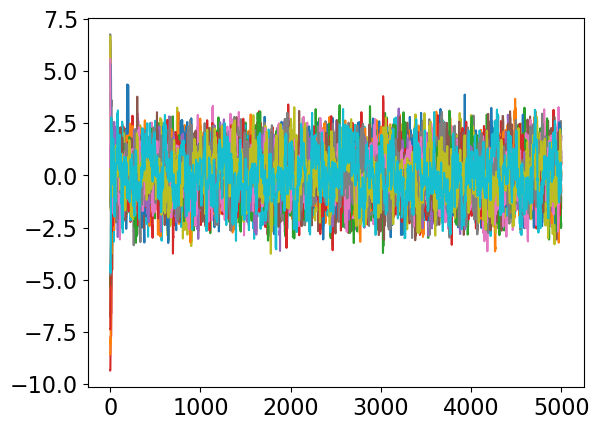

In [15]:
chain = sampler.get_chain()["model_0"]
print(chain.shape)
for w in range(nwalkers):
    plt.plot(chain[:, 0, w, 0])

Compare your output chains to the injected Gaussian distribution. They should match. Make sure when you plot the histogram, you set `density=True`. 

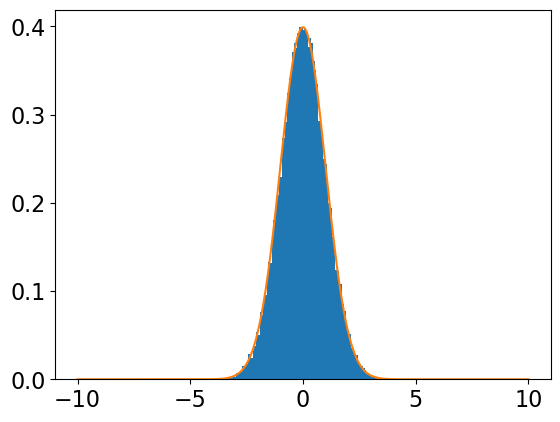

In [16]:
plt.hist(chain[1000:].flatten(), bins=100, density=True)
# chain[1000:].flatten() 会把多维数组展平为一维数组，这样就可以直接用来画直方图了。
#plt.hist(chain[1000:].flatten(), bins=100, density=True) 
#会将直方图归一化，使得总面积为1，这样就可以直接与概率密度函数进行比较。
#chain.flatten()
plt.plot(x_vals, np.exp(log_like_gauss(x_vals)))

## Task 3: Parallel Tempering

Now we will add parallel tempering. In order to examine the effect of addering tempering, we are going to look at a 1D distribution with two Gaussian peaks with different weights. We have provided the log Likelihood function for this exercise. You just set the x limits to proper normalize the distribution.

Parallel tempering works by supressing the Log Likelihood in comparison to the log prior: `1/T * logL + logp`. This effect lowers the peaks making it easier for higher temperature chains to traverse a low-Likelihood portion of the Likelihood surface. This helps to properly sample distributions with multiple posterior modes. 

We will start by sampling without tempering to see how well that does. Then we will add tempering to see the improvement. 

$1/T * log L+log p$，其中L是似然概率，p是先验概率，先验概率是不可以改变的。否则会让我们的撒点跑出我们所预想的空间，L是可以操作的，将其变得平滑，这样就可以发现两个峰。

In [17]:
from scipy.special import logsumexp

class LogLikeTwoGuass:
    def __init__(self, x_min: float, x_max: float):
        num_for_norm = 100000
        self.norm = 1.0
        x_vals = np.linspace(x_min, x_max, num_for_norm)
        y_vals = np.array([np.exp(self.log_like_two_gauss(x_tmp)) for x_tmp in x_vals])
        self.norm = np.trapz(y_vals, x=x_vals)
        
    def log_like_two_gauss(self, x):
        return logsumexp(np.array([(np.log(0.2) + -0.5 * (x - 50.0) ** 2), (np.log(0.8) + -0.5 * (x + 50.0) ** 2)]), axis=0) - np.log(self.norm)

In [18]:
# 将
def my_trapz_replacement(y, x=None, dx=1.0, axis=-1):
    return np.trapezoid(y, x=x, dx=dx, axis=axis)

# 2. 如果 numpy 丢了东西，就把这个“翻译官”派驻到 numpy 里面去
if not hasattr(np, 'trapz'):
    np.trapz = my_trapz_replacement

In [20]:
like = LogLikeTwoGuass(-1000.0, 1000.0)

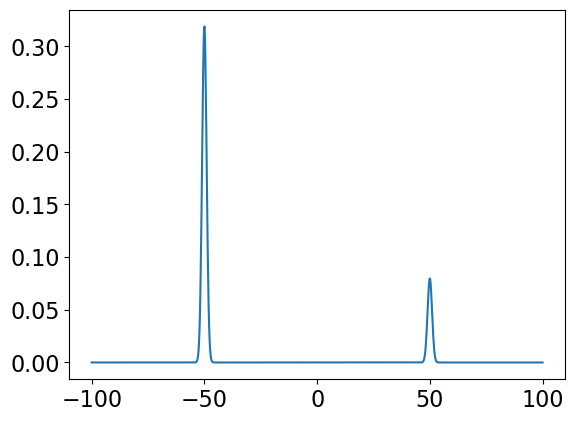

In [21]:
x_vals = np.linspace(-100.0, 100.0, 1000)
# notice the `exp` in there because we are working with the log of the likelihood.
plt.plot(x_vals, np.exp(like.log_like_two_gauss(x_vals)))
#plt.plot(x_vals, np.exp(np.array([like.log_like_two_gauss(x_tmp) for x_tmp in x_vals])))


Start with a non-tempered sampler. Run it and plot the histogram over the injected Likelihood. 

In [22]:
# 1. 定义先验 (Prior)
# 只有一个参数，我们给它一个均匀分布的先验，范围是 -100 到 100。
prior = ProbDistContainer({
    0: uniform_dist(-100.0, 100.0) 
})
# 2. 初始化 Eryn 采样器 (EnsembleSampler)
nwalkers = 30  # 我们雇佣 20 个漫步者（醉汉）同时去搜索
ndim = 1       # 参数的维度只有 1 维（也就是 x）
# 只传入核心参数，其他关键字参数（kwargs）留作默认值
sampler = EnsembleSampler(
    nwalkers, 
    ndim, 
    like.log_like_two_gauss,
    priors=prior
)



所以在分割的时候不用写ndim
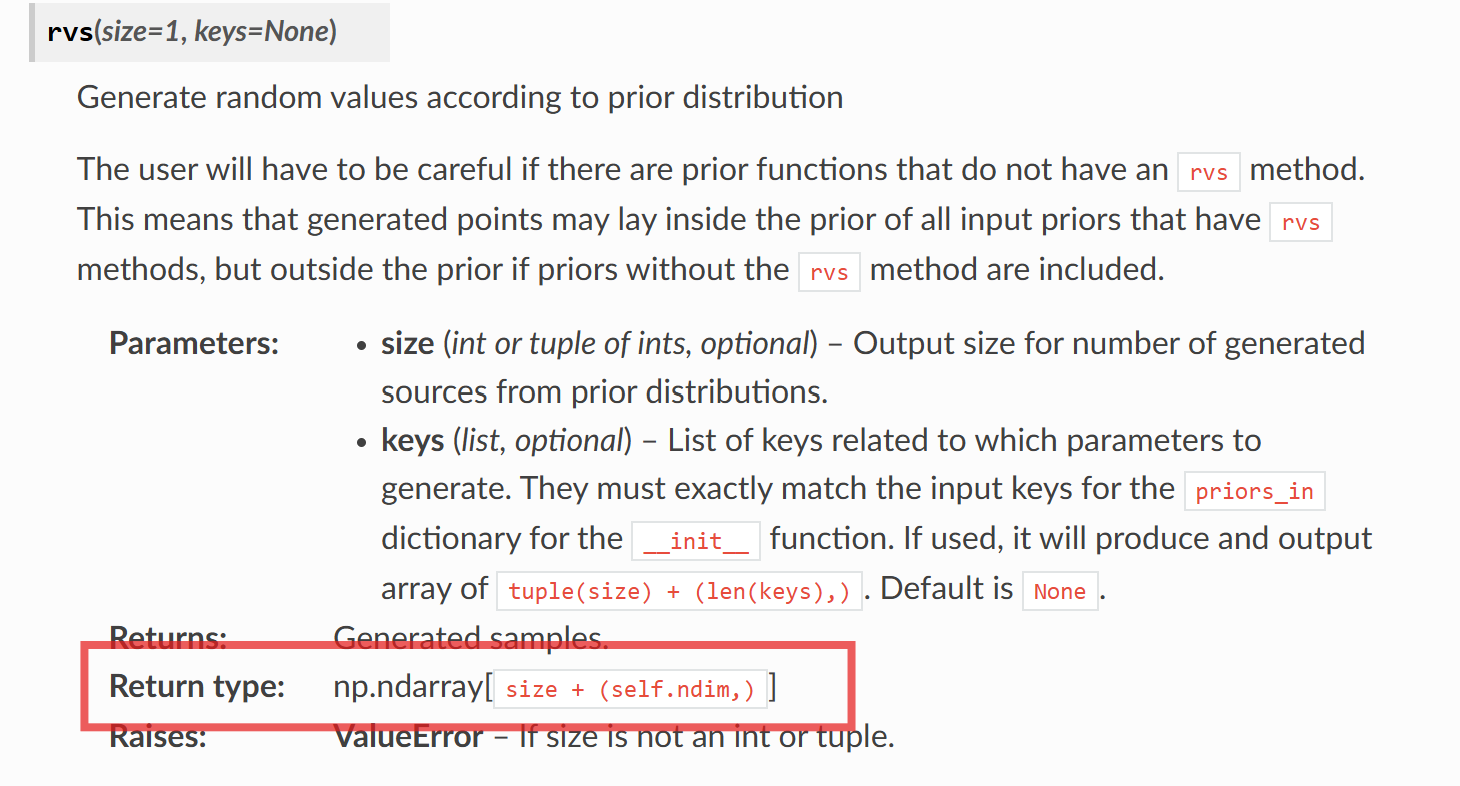

In [23]:
startpoint=np.random.uniform(-90.0, 90.0, size=(1,nwalkers,1, ndim))  
# 每个漫步者的初始位置随机分布在 -90 到 90 之间
#np.random.uniform(a, b, size) 生成一个形状为 size 的数组，
# 数组中的每个元素都是在 [a, b) 区间内均匀分布的随机数。
start_state = State(startpoint)
#state 是 Eryn 里用来表示当前参数状态的对象。
# 它是一个字典，键是参数的索引（这里只有一个参数，所以是 0）
# 值是一个形状为 (1, nwalkers, 1, ndim) 的数组，表示每个漫步者在这个参数上的位置。

# 因为有 20 个醉汉同时在走，如果每个人走 5000 步，总共就是 10 万个采样点。
n_steps = 5000
sampler.run_mcmc(start_state, n_steps, progress=True)

100%|██████████| 5000/5000 [00:11<00:00, 446.65it/s]


(5000, 1, 30, 1, 1)


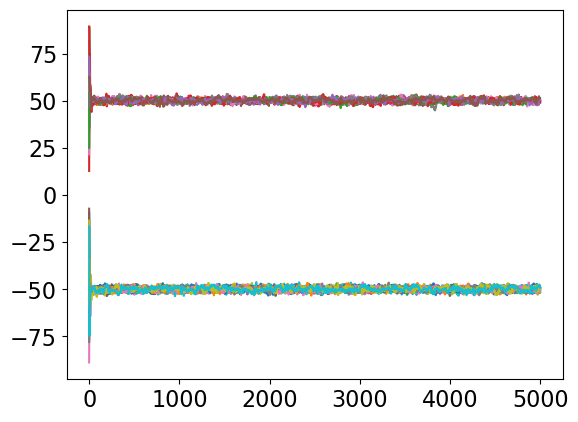

In [24]:
chain = sampler.get_chain()["model_0"]
print(chain.shape)
for w in range(nwalkers):
    plt.plot(chain[:, 0, w, 0])

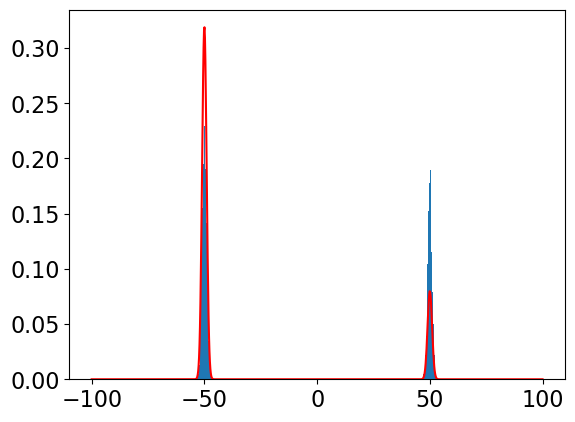

In [25]:
plt.hist(chain[1000:].flatten(), bins=300, density=True)
# chain[1000:].flatten() 会把多维数组展平为一维数组，这样就可以直接用来画直方图了。
#plt.hist(chain[1000:].flatten(), bins=100, density=True) 
#会将直方图归一化，使得总面积为1，这样就可以直接与概率密度函数进行比较。
#chain.flatten()
plt.plot(x_vals, np.exp(like.log_like_two_gauss(x_vals)), color='red')

### Question

The plot should not look correct. Why do you think this is? When not using tempering, what determines the number of walkers inhabiting each peak?

因为峰两个之间有难以逾越的鸿沟，这个的跨越需要点的随机投掷筛子判断，但是跨越是很难的。所以完全由我们开始撒点的初始位置确定。

Now add temperatures by providing `tempering_kwargs` kwarg to `EnsembleSampler.

Useful Documentation:
* [EnsembleSampler](https://mikekatz04.github.io/Eryn/html/user/ensemble.html#eryn.ensemble.EnsembleSampler)
* [TemperatureControl](https://mikekatz04.github.io/Eryn/html/user/temper.html#eryn.moves.tempering.TemperatureControl)

In [26]:
prior = ProbDistContainer({
    0: uniform_dist(-100.0, 100.0) 
})
nwalkers = 30 
ndim = 1 
# 设置平行回火的参数包
tempering_kwargs={
    "ntemps": 10,           # 物理意义：我们同时克隆 10 个平行宇宙（10 层温度梯子）。
                            # 最底层 T=1（常温），最高层 T 极大（高温）。       
    "Tmax": np.inf,         # 物理意义：最高层楼的温度。设为无穷大 (inf) 意味着在最高层，
                            # 似然函数被彻底压平，醉汉完全感受不到山峰和山谷，变成纯随机游走。            
    "adaptive": True,       # 物理意义：开启“动态调温”。Eryn 会在跑的时候观察醉汉们在不同楼层间
                            # 交换位置的顺畅程度，自动调整中间 8 层楼的温度间距，保证上下楼畅通无阻。          
    "stop_adaptation": 500 # 物理意义：在跑了 500步（Burn-in 预热期）之后，就固定住楼层温度，
                            # 不再调整了，保证后续采样的严格统计性质。
}
# 只传入核心参数，其他关键字参数（kwargs）留作默认值
sampler = EnsembleSampler(
    nwalkers, 
    ndim, 
    like.log_like_two_gauss,
    priors=prior,
    tempering_kwargs=tempering_kwargs
)


Sample start points again from the prior with shape `(ntemps, nwalkers, 1, ndim)`. Then run the sampler.

In [27]:
ntemps = 10
start_point = prior.rvs(size=(ntemps, nwalkers,1))
start_state = State(start_point)
sampler.run_mcmc(start_state, 10000, progress=True)


100%|██████████| 10000/10000 [02:26<00:00, 68.33it/s]


Plot the chains over the injection distribution.

(10000, 10, 30, 1, 1)


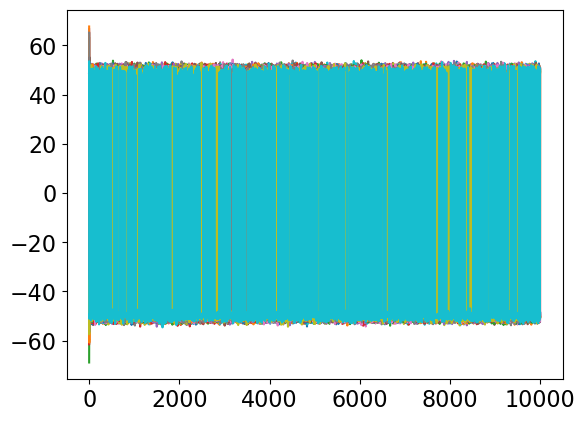

In [28]:
chain = sampler.get_chain()["model_0"]
print(chain.shape)
for w in range(nwalkers):
    plt.plot(chain[:, 0, w, 0])


Now the plots should match very weel. Can you describe the change that took place?

注意，一定要选``chain[500:,0]``,这个0就是选择温度为最低层，也就是1的，这才是真的数据。

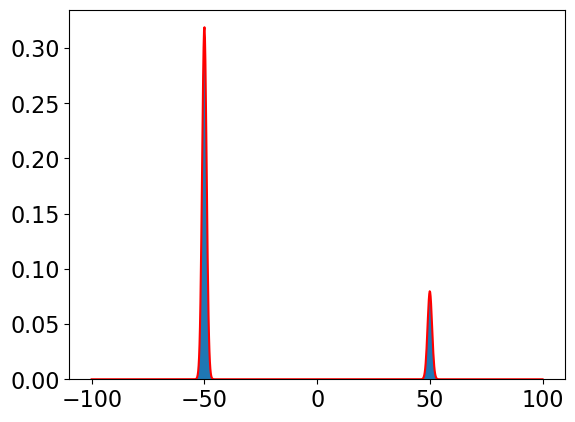

In [29]:
plt.hist(chain[500:,0].flatten(), bins=300, density=True)
#plt.hist(chain[1000:].flatten(), bins=100, density=True) 
#会将直方图归一化，使得总面积为1，这样就可以直接与概率密度函数进行比较。
#chain.flatten()
plt.plot(x_vals, np.exp(like.log_like_two_gauss(x_vals)), color='red')

## Task 6: Add GWs!

Now we will add GW signals in the form of the simple Sinusoid we used in the first tutorial. We will start with the waveform function. Set up the `DataResidualArray` (inject whatever parameter you would like), `SensitivityMatrix`, and `AnalysisContainer`. Remember, we do not have a response on this signal, so the sensitivity curve should be `LISASens`. 

In [30]:
from lisatools.datacontainer import DataResidualArray
from lisatools.analysiscontainer import AnalysisContainer
from lisatools.sensitivity import SensitivityMatrix, LISASens

We will add the waveform for you.

In [31]:
def sinusoidal_waveform(A: float, f0: float, phi0: float, t: np.ndarray, **kwargs):
    h1 = A * np.sin(2 * np.pi * (f0 * t) + phi0)
    h2 = A * np.cos(2 * np.pi * (f0 * t) + phi0)
    return [h1, h2]

Generate the injection data, input it into a `DataResidualArray`, load a `SensitivityMatrix`, and store everything in an `AnalysisContainer`, including the sinusoidal waveform generator. 

In [32]:
dt = 10.0
t_arr = np.arange(100000) * dt
# np.arange(100000) * dt 会生成一个长度为 100000 的数组，元素是从 0 开始，每个元素递增 dt 的值。
# 也就是说，t_arr 中的元素分别是 0, dt, 2*dt, ..., (99999)*dt。
data = DataResidualArray(sinusoidal_waveform(1e-21, 2e-3, np.pi / 3, t_arr), dt=dt)
sens_mat = SensitivityMatrix(data.f_arr, [LISASens, LISASens])
analysis = AnalysisContainer(data, sens_mat, signal_gen=sinusoidal_waveform)

/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:655: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:657: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:659: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:664: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:666: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np.pi * frq / C_SI) ** 2


Calculate the SNR of the injection. (`AnalysisContainer.calculate_signal_snr`)

In [70]:
analysis.calculate_signal_snr(1e-21, 2e-3, 0.0, t_arr)

(np.float64(41.3485755838877), np.float64(20.674287791938163))

Biuld the prior distributions for the three parameters.

In [33]:
priors = ProbDistContainer({
    0: uniform_dist(9e-22, 3e-21),
    1: uniform_dist(1.5e-3, 2.5e-3),
    2: uniform_dist(0.0, 2 * np.pi)
})

Initialize the sampler. For the Likelihood function, you can use `AnalysisContainer.eryn_likelihood_function`. For  now, we will not use tempering. This generation scheme is not efficient in terms of the Likelihood evaluation time. So, we will just run this as a quick example. You can run it longer later on and/or parallelize it with Eryn's `pool` capabilities. This basic example we are using illustrates the need for fast waveform generation capabilities. 

In [34]:
ndim = 3
nwalkers=20
sampler = EnsembleSampler(
    nwalkers,
    ndim, 
    analysis.eryn_likelihood_function,
    priors,
    args=(t_arr,)
)


Generate the start state and run the sampler. 

In [75]:
start_state = State(priors.rvs(size=(1, nwalkers, 1)))
sampler.run_mcmc(start_state, 10000, progress=True)


100%|██████████| 10000/10000 [12:43<00:00, 13.10it/s]


You can examine the chains and/or Likelihood values if you want, but you will likely have to run it for longer to get any reasonable results. 

(10100, 1, 20, 1, 3)


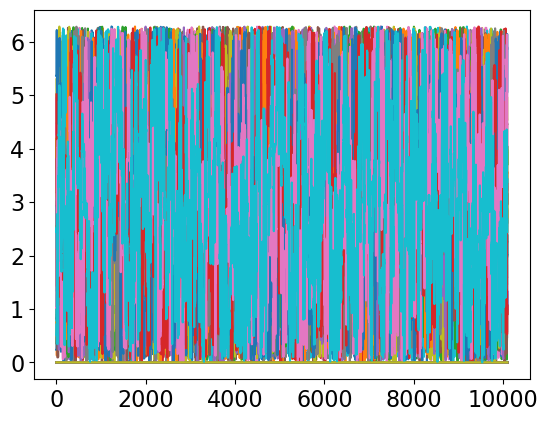

In [79]:
chain = sampler.get_chain()["model_0"]
print(chain.shape)
for w in range(nwalkers):
    plt.plot(chain[:, 0, w, 0])

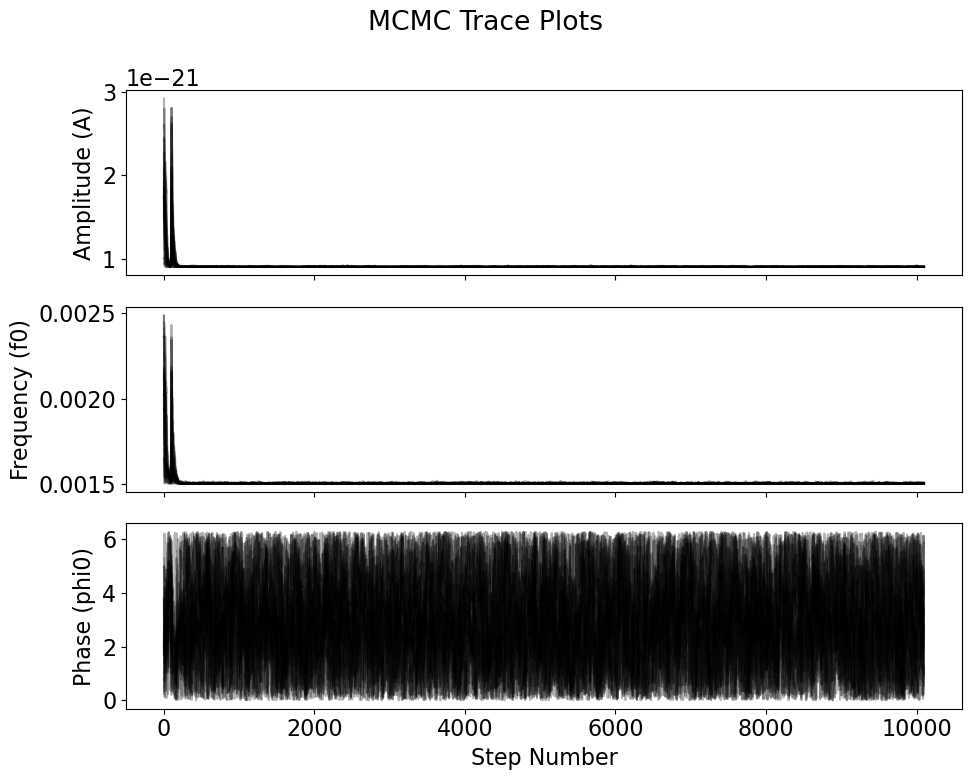

In [83]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
labels = ["Amplitude (A)", "Frequency (f0)", "Phase (phi0)"]

# 提取所有步数、所有漫步者在常温层(T=1)的数据
for i in range(3):
    ax = axes[i]
    # 取出第 i 个参数的轨迹：chain[:, 0, :, 0, i] -> shape (10000, 20)
    ax.plot(chain[:, 0, :, 0, i], color="k", alpha=0.3)
    ax.set_ylabel(labels[i])

axes[-1].set_xlabel("Step Number")
plt.suptitle("MCMC Trace Plots")
plt.tight_layout()
plt.show()

In [ ]:
burn_in = 2000
flat_samples = chain[burn_in:, 0, :, 0, :].reshape(-1, 3)
print(f"压平后的有效样本数: {flat_samples.shape}")

压平后的有效样本数: (162000, 3)


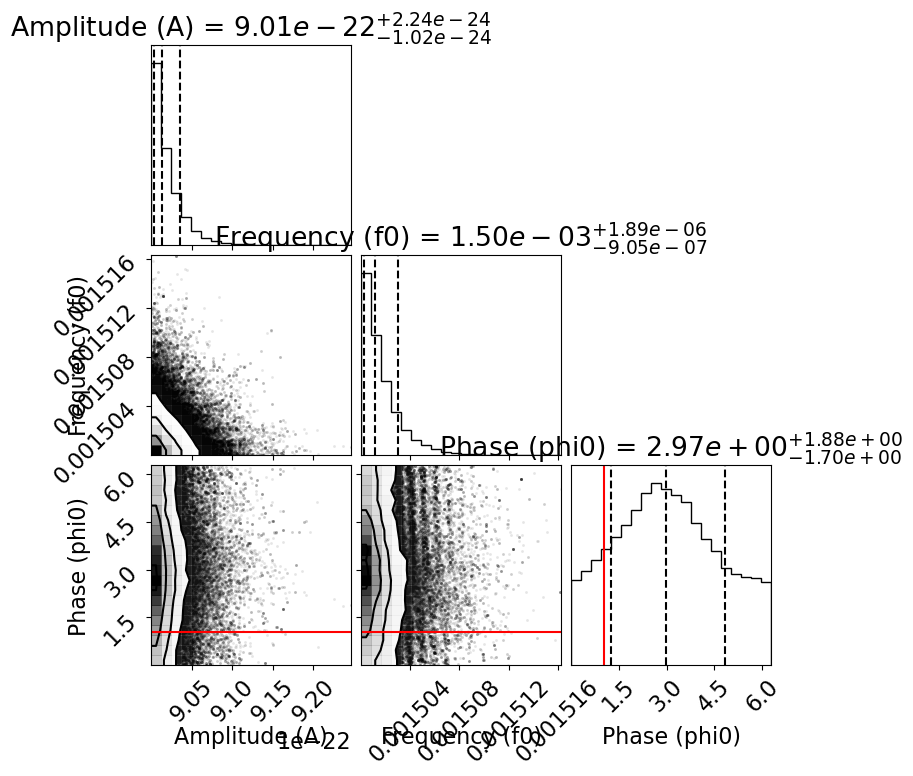

In [82]:
import corner

# 我们在生成信号时注入的真实参数 (True values)
truths_values = [1e-21, 2e-3, np.pi/3]

# 画边角图
fig = corner.corner(
    flat_samples, 
    labels=labels, 
    truths=truths_values,        # 画出真实的十字准星
    truth_color="red",           # 真实值为红色
    show_titles=True,            # 标题显示最佳值和误差
    title_fmt=".2e",             # 科学计数法格式化
    quantiles=[0.16, 0.5, 0.84]  # 画出 1 sigma 的误差线
)

plt.show()

### Question

What types of things can we do to speed up this calculation? Translate this into the waveform environment. 

## Task 4: Calculate the evidence

Calculate the evidence for the single-peaked Gaussian distribution using thermodynamic integration from Eryn. Use 10 walkers and 50 temperatures to start. You can play with these numbers later and observe their effect on the measurement. Use the `burn` kwarg when running `run_mcmc`. **Important**: for the `tempering_kwargs` keyword argument for `EnsembleSampler`, you must add to the dictionary: `stop_adaptation=burn`. This will adapt the temperatures during burn in and then hold them fixed while recording samples. 

Useful documentation:
* [thermodynamic_integration_log_evidence](https://mikekatz04.github.io/Eryn/html/user/utils.html#eryn.utils.utility.thermodynamic_integration_log_evidence)

$Z$ 的物理本质：模型的“平均得分”公式是 $Z = \int L(\theta) p(\theta) d\theta$。$L(\theta)$ 是在特定参数下，模型拟合数据的得分。$p(\theta)$ 是先验，可以看作是你在参数空间里分配的“权重”。你把这两个乘起来再积分，其实是在算：“在先验规定的范围内，这个模型所有可能形态的平均拟合得分”。如果 $Z$ 很大，说明这个模型即使在参数不确定的情况下，随便抓一组合理的参数，都能很好地解释数据。 这不就是证明这个模型很优秀的“证据”吗？

假设我们观测到了一个信号，现在有两个模型：模型 A（精准但保守）：物理限制很死，先验 $p$ 的范围很窄（比如只允许参数在 1 到 2 之间）。因为范围窄，积分面积为 1，所以这段区间内的 $p(\theta)$ 的高度很高。模型 B（万能但臃肿）：物理机制不明，你不得不给一个极宽的先验（比如允许参数在 -100 到 100 之间）。因为范围宽，为了保证积分为 1，它在每个点上的 $p(\theta)$ 被摊得极薄（极低）。奇迹发生了：哪怕模型 B 在最佳参数处的似然度 $L$ 和模型 A 一样高，但因为模型 B 的先验 $p(\theta)$ 太薄了，当计算积分 $Z = \int L \cdot p \, d\theta$ 时，模型 B 的 $Z$ 会被严重拉低！所以，$Z$ 不仅是对拟合优度的奖励，更是对**模型过度复杂、先验过度宽泛的惩罚**。你先验给得越随意、越宽泛，你的证据 $Z$ 就越低，你的模型就在竞争中被淘汰了。

热力学公式为

$$\ln Z = \int_0^1 \langle \ln L \rangle_\beta d\beta$$
其中$\langle \ln L \rangle_\beta$是在$\beta$温度下的均值

In [35]:
# imports
from eryn.utils.utility import thermodynamic_integration_log_evidence

Initialize the sampler. Run the MCMC.

In [48]:
nwalkers = 10
ntemps = 100
burn = 2000
sampler_pt_2 = EnsembleSampler(nwalkers,
                                1, 
                                log_like_gauss, prior,
                                tempering_kwargs=dict(stop_adaptation=burn, ntemps=ntemps, Tmax=np.inf))
start_point = prior.rvs(size=(ntemps, nwalkers, 1))
start_state = State(start_point)
sampler_pt_2.run_mcmc(start_state, 10000, burn=burn, progress=True)
# burn 就是burn-in的时间，burn-in是stop_adaptation和平行退火的时间同步，平行退火开始计算


100%|██████████| 10000/10000 [01:24<00:00, 117.67it/s]


1) Compute the average likelihood across all samples and walkers **within** each temperature chain.
2) Get the inverse temperatures (`betas`) out of the sampler backend and make sure they are the same over the entire run.
3) Calculate the evidence.

Useful Documentation:
* [thermodynamic_integration_log_evidence](https://mikekatz04.github.io/Eryn/html/user/utils.html#eryn.utils.utility.thermodynamic_integration_log_evidence)
* [Backend.get_log_like](https://mikekatz04.github.io/Eryn/html/user/backend.html#eryn.backends.Backend.get_log_like)
* [Backend.get_betas](https://mikekatz04.github.io/Eryn/html/user/backend.html#eryn.backends.Backend.get_betas)

In [45]:
logl_avg = sampler_pt_2.get_log_like()
print(logl_avg.shape)
logl_avg = sampler_pt_2.get_log_like().mean(axis=(0, 2))
betas = sampler_pt_2.get_betas()
print(betas.shape)
#print(betas)

(10000, 50, 10)
(10000, 50)


In [49]:
logl_avg = sampler_pt_2.get_log_like().mean(axis=(0, 2))
betas = sampler_pt_2.get_betas()[-1]
#[-1] 表示我们只取最后一步（第 10000 步）的那 50 个 $\beta$ 值，
# 作为一个一维数组。这将作为我们画积分曲线的 X 轴。
assert np.all(betas == sampler_pt_2.get_betas()[0])

logz = thermodynamic_integration_log_evidence(betas, logl_avg)
print(logz)


(np.float64(-8.62002297340766), np.float64(21.765789513072992))


assert 是 Python 里的断言，意思是“如果后面的条件为假，程序就立刻报错崩溃”。
之前设置的``stop_adaptation=burn``,如果在生产期（burn 之后），温度梯子还在变，那么马尔可夫链就不满足细致平衡（Detailed Balance），算出来的积分就是纯纯的垃圾。

## Task 5: Model Selection

Perform model comparison between a Gaussian and Cauchy pulse using thermodynamic integration of the evidence.

Here are the pulse functions and the Likelhiood. We will assume each pulse has an amplitude and mean parameter. We set the standard deviation to be 1. 

In [63]:
from scipy.stats import cauchy
def gaussian_pulse(x, a, b):
    f_x = a * np.exp(-((x - b) ** 2) / (2 * 1.0 ** 2))
    return f_x

def cauchy_pulse(x, a, b):
    f_x = a * cauchy.pdf(x - b)
    return f_x

def log_like_fn(params, t, data, sigma, which_template):

    pulse_gen = gaussian_pulse if which_template == "gauss" else cauchy_pulse
    template = pulse_gen(t, *params)
    # 和上文对应 pulse_gen(x,a,b)，a,b是个猜测的列表丢进去
    ll = -0.5 * np.sum(((template - data) / sigma) ** 2,axis=-1)
    return ll

``axis=n``是指“沿着哪个轴的方向去压扁”。

0:行

1:列

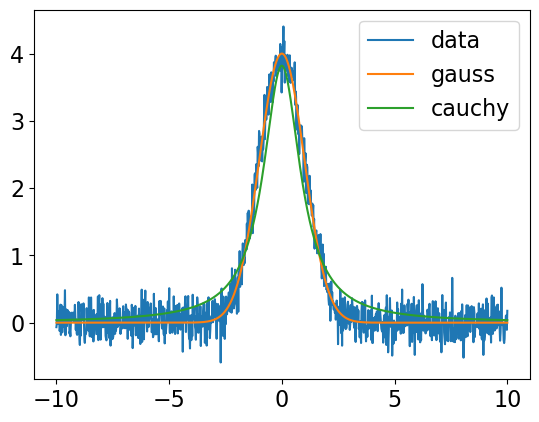

In [60]:
t_vals = np.linspace(-10.0, 10.0, 1000)
sigma = 0.2
amp_true = 4.0
mean_true = 0.0
true_data = gaussian_pulse(t_vals, amp_true, mean_true)
data = true_data + np.random.randn(*t_vals.shape) * sigma
# np.random.randn,生成一个t_vals.shape的白噪声
#*是解包操作符（Unpacking Operator），
cauchy_data = cauchy_pulse(t_vals, amp_true * 3, mean_true)
plt.plot(t_vals, data, label="data")
plt.plot(t_vals, true_data, label="gauss")
plt.plot(t_vals, cauchy_data, label="cauchy")
plt.legend()

In [58]:
print(t_vals.shape)
print(t_vals)
print(data.shape)

(1000,)
[-10.          -9.97997998  -9.95995996  -9.93993994  -9.91991992
  -9.8998999   -9.87987988  -9.85985986  -9.83983984  -9.81981982
  -9.7997998   -9.77977978  -9.75975976  -9.73973974  -9.71971972
  -9.6996997   -9.67967968  -9.65965966  -9.63963964  -9.61961962
  -9.5995996   -9.57957958  -9.55955956  -9.53953954  -9.51951952
  -9.4994995   -9.47947948  -9.45945946  -9.43943944  -9.41941942
  -9.3993994   -9.37937938  -9.35935936  -9.33933934  -9.31931932
  -9.2992993   -9.27927928  -9.25925926  -9.23923924  -9.21921922
  -9.1991992   -9.17917918  -9.15915916  -9.13913914  -9.11911912
  -9.0990991   -9.07907908  -9.05905906  -9.03903904  -9.01901902
  -8.998999    -8.97897898  -8.95895896  -8.93893894  -8.91891892
  -8.8988989   -8.87887888  -8.85885886  -8.83883884  -8.81881882
  -8.7987988   -8.77877878  -8.75875876  -8.73873874  -8.71871872
  -8.6986987   -8.67867868  -8.65865866  -8.63863864  -8.61861862
  -8.5985986   -8.57857858  -8.55855856  -8.53853854  -8.51851852
  

在 MCMC 引擎里，它是这样被调用的：引擎产生了一组动态的猜测参数，比如猜测振幅 $a=4.1$，位置 $b=0.1$。它把这两个数打包成一个数组：[4.1, 0.1]。引擎准备调用 log_like_fn。它会把动态数组 [4.1, 0.1] 硬塞进第一个位置，也就是赋值给了 params。剩下的位置怎么办？引擎会去你初始化 EnsembleSampler 时写的那个 args=(...) 里拿东西。你会写类似这样的代码：args=(t_vals, data, sigma, "gauss")。完美对接！params = [4.1, 0.1]t = t_valsdata = datasigma = sigmawhich_template = "gauss"里面那个 *params 又是什么鬼？因为你定义的理论脉冲函数是 gaussian_pulse(x, a, b)，它需要三个独立的参数。此时你手里的 params 是一个包含两个数的数组 [4.1, 0.1]。如果直接写 pulse_gen(t, params)，它会以为 a 是一个数组，而 b 没传值。加上 * 解包：pulse_gen(t, *params) 就变成了 pulse_gen(t, 4.1, 0.1)，精准对应上了 a 和 b！

We need to run separate sampler objects for each model. 

The priors are identical really for the two models. The amplitude prior should span the injection values. The mean prior should span the domain of time.

Initialize the priors for each, the sampler for each, sample a start point for each, and run both samplers with the setup we used above. 

In [64]:
priors = {}
samplers = {}
burn = 1000
for name in ["gauss", "cauchy"]: 
    priors[name] = ProbDistContainer({
    0: uniform_dist(0.0, 40.0),
    1: uniform_dist(t_vals.min(), t_vals.max())
})
    samplers[name] = EnsembleSampler(
        nwalkers,
        2,
        log_like_fn,
        priors,
        branch_names=[name],
        tempering_kwargs=dict(stop_adaptation=burn, ntemps=ntemps, Tmax=np.inf),
        args=(t_vals, data, sigma, name)
    )

    start_point = priors[name].rvs(size=(ntemps, nwalkers, 1))
    start_state = State({name: start_point})
    samplers[name].run_mcmc(start_state, 10000, burn=burn, progress=True)


100%|██████████| 10000/10000 [06:16<00:00, 26.57it/s]


Repeat the calculation from above for both models. Then find Bayes Factor.

In [65]:
logz_out = {}
for name in ["gauss", "cauchy"]: 
    logls = samplers[name].get_log_like().mean(axis=(0, 2))
    betas = samplers[name].get_betas()
    assert np.all(betas[-1] == betas[0])
    logz, dlogz = thermodynamic_integration_log_evidence(betas[-1], logls)
    print(name, logz, dlogz)
    logz_out[name] = logz

print("2log(Bayes Factor):", 2 * (logz_out["gauss"] - logz_out["cauchy"]))

gauss -495.8153934119569 39.47827505649724
cauchy -987.2658718875184 32.11016989782354
2log(Bayes Factor): 982.900956951123


贝叶斯因子的物理意义是两个模型概率的比值：$\mathcal{B} = \frac{Z_{\text{gauss}}}{Z_{\text{cauchy}}}$。
你现在算出的是它的自然对数 $\ln \mathcal{B} \approx 1007$。
这意味着，在观测到这堆数据后，宇宙真相是高斯脉冲的概率，是柯西脉冲的 $e^{1007}$ 倍！

### Question

If we change the noise, what effect will this have on our results?

改变噪声，噪声变大，会发现两个模型都凑合，则$\mathcal{B}$就会减小。如果改小噪声，贝叶斯因子会进一步的增加。